Carregando datasets...
Treino:    39235 amostras | 23 features
Validação: 8443 amostras  | 23 features
Classes (8): ['A', 'B', 'F', 'L', 'N', 'R', 'V', 'f']
Scaler e encoder salvos em ArduinoCode/
checkpoint directory created: ./model
saving model version 0.0

Iniciando treinamento da KAN...


| train_loss: 2.47e-01 | test_loss: 5.12e-01 | reg: 2.89e+02 | : 100%|█| 25000/25000 [05:43<00:00, 7


saving model version 0.1


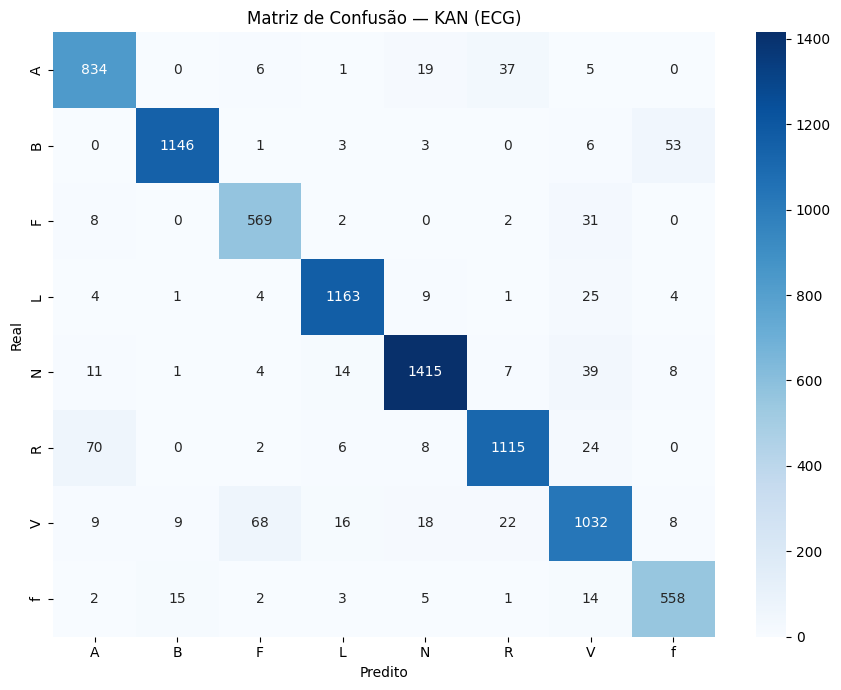


              precision    recall  f1-score   support

           A     0.8891    0.9246    0.9065       902
           B     0.9778    0.9455    0.9614      1212
           F     0.8674    0.9297    0.8975       612
           L     0.9627    0.9604    0.9616      1211
           N     0.9580    0.9440    0.9509      1499
           R     0.9409    0.9102    0.9253      1225
           V     0.8776    0.8731    0.8753      1182
           f     0.8843    0.9300    0.9066       600

    accuracy                         0.9276      8443
   macro avg     0.9197    0.9272    0.9231      8443
weighted avg     0.9286    0.9276    0.9279      8443



In [2]:
# =============================================================================
# KAN - ECG CLASSIFICATION + TINYML EXPORT (ESP32)
# Versão unificada e corrigida
# =============================================================================

import os
import re
import random
import numpy as np
import pandas as pd
import sympy as sp
import joblib
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.fft import rfft, rfftfreq

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from kan import KAN


# =============================================================================
# BLOCO 1 — EXTRAÇÃO DE FEATURES (ÚNICA VERSÃO, usada em treino e geração do .h)
# =============================================================================

def extract_wavelet_features(signal, wavelet='db4', level=4):
    """
    Retorna a energia de cada banda wavelet (aproximação + detalhes).
    level=4 → 5 coeficientes no total.
    """
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    return [float(np.sum(c ** 2)) for c in coeffs]


def spectral_band_features(signal, fs=360):
    """
    Energia espectral em três bandas de frequência:
      band1: 0–5 Hz   (ondas lentas, linha de base)
      band2: 5–15 Hz  (complexo QRS principal)
      band3: 15–40 Hz (atividade de alta frequência, ruído muscular)
    """
    yf = np.abs(np.fft.rfft(signal))
    xf = np.fft.rfftfreq(len(signal), 1 / fs)

    band1 = float(yf[(xf >= 0)  & (xf < 5)].sum())
    band2 = float(yf[(xf >= 5)  & (xf < 15)].sum())
    band3 = float(yf[(xf >= 15) & (xf < 40)].sum())

    return [band1, band2, band3]


def extract_features(signal, fs=360):
    """
    Extrai todas as features usadas no treino.
    Esta é a ÚNICA função de extração — usada tanto para montar o dataset
    de treino/validação quanto para gerar o dataset.h para o ESP32.

    Ordem das features (total = 22):
      [0-10]  Estatísticas temporais (11 features)
      [11]    Amplitude do pico R
      [12]    Largura do QRS (segundos)
      [13]    Frequência dominante (Hz)
      [14]    Energia espectral total (FFT)
      [15-17] Bandas espectrais (3 features)
      [18-22] Energias wavelet db4 level=4 (5 features)
    """
    signal = signal.astype(np.float32)

    # ---- Estatísticas temporais ----
    features = [
        float(np.mean(signal)),
        float(np.std(signal)),
        float(np.min(signal)),
        float(np.max(signal)),
        float(np.ptp(signal)),                         # peak-to-peak
        float(np.sum(signal ** 2)),                    # energia total
        float(np.sum(np.abs(signal))),                 # soma dos valores absolutos
        float(np.max(np.abs(np.diff(signal)))),        # maior variação entre amostras
        float(len(signal)),                            # comprimento do sinal
        float(skew(signal)),
        float(kurtosis(signal)),
    ]

    # ---- Detecção do pico R ----
    peaks, _ = find_peaks(signal, distance=int(0.4 * fs))

    if len(peaks) > 0:
        # Seleciona o pico mais próximo do centro do segmento
        center = len(signal) // 2
        peak = peaks[np.argmin(np.abs(peaks - center))]
        r_peak_amp = float(signal[peak])
    else:
        peak = -1
        r_peak_amp = 0.0

    features.append(r_peak_amp)

    # ---- Largura do QRS ----
    if peak != -1:
        threshold = signal[peak] * 0.5

        left = peak
        while left > 0 and signal[left] > threshold:
            left -= 1

        right = peak
        while right < len(signal) - 1 and signal[right] > threshold:
            right += 1

        qrs_width = float((right - left) / fs)
    else:
        qrs_width = 0.0

    features.append(qrs_width)

    # ---- FFT: frequência dominante e energia total ----
    yf = np.abs(rfft(signal))
    xf = rfftfreq(len(signal), 1 / fs)

    dominant_freq   = float(xf[np.argmax(yf)])
    spectral_energy = float(np.sum(yf))

    features.append(dominant_freq)
    features.append(spectral_energy)

    # ---- Bandas espectrais ----
    features.extend(spectral_band_features(signal, fs))

    # ---- Wavelet ----
    features.extend(extract_wavelet_features(signal, wavelet='db4', level=4))

    return features   # 22 features no total


# =============================================================================
# BLOCO 2 — CONSTRUÇÃO DO DATASET
# =============================================================================

def build_dataset(root_dir, fs=360):
    """
    Percorre root_dir/<classe>/*.csv e extrai features de cada sinal.
    Detecta automaticamente a coluna correta no CSV.
    Retorna X (features), y (nomes das classes).
    """
    X, y = [], []

    for class_name in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file in os.listdir(class_path):
            if not file.endswith(".csv"):
                continue

            df = pd.read_csv(os.path.join(class_path, file))

            if "amplitude" in df.columns:
                signal = df["amplitude"].values
            elif "channel_0" in df.columns:
                signal = df["channel_0"].values
            else:
                signal = df.values.flatten()

            X.append(extract_features(signal, fs))
            y.append(class_name)

    return np.array(X, dtype=np.float32), np.array(y)


# =============================================================================
# BLOCO 3 — CARREGAMENTO DOS DADOS E PRÉ-PROCESSAMENTO
# =============================================================================

print("=" * 60)
print("Carregando datasets...")
print("=" * 60)

X_train, y_train = build_dataset("dataset_split_2/train")
X_val,   y_val   = build_dataset("dataset_split_2/val")

print(f"Treino:    {X_train.shape[0]} amostras | {X_train.shape[1]} features")
print(f"Validação: {X_val.shape[0]} amostras  | {X_val.shape[1]} features")

# Codificação dos rótulos
encoder      = LabelEncoder()
y_train_enc  = encoder.fit_transform(y_train)
y_val_enc    = encoder.transform(y_val)
num_classes  = len(encoder.classes_)
class_names  = list(encoder.classes_)

print(f"Classes ({num_classes}): {class_names}")

# Escalonamento — IMPORTANTE: fit apenas no treino
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Serializa o scaler para reutilização futura (ex.: generate_dataset_h)
os.makedirs("ArduinoCode", exist_ok=True)
joblib.dump(scaler,  "ArduinoCode/scaler.pkl")
joblib.dump(encoder, "ArduinoCode/encoder.pkl")
print("Scaler e encoder salvos em ArduinoCode/")

# Conversão para tensores PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc,    dtype=torch.long)
y_val_t   = torch.tensor(y_val_enc,      dtype=torch.long)


# =============================================================================
# BLOCO 4 — DEFINIÇÃO E TREINO DA KAN
# =============================================================================

n_features = X_train_t.shape[1]

model = KAN(
    width=[n_features, 16, 8, num_classes],
    grid=5,
    k=3,
)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input':  X_val_t,
    'test_label':  y_val_t,
}

# Pesos para lidar com desbalanceamento de classes
pesos_classes = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc,
)
pesos_tensor = torch.tensor(pesos_classes, dtype=torch.float32)
loss_fn = nn.CrossEntropyLoss(weight=pesos_tensor)

print("\nIniciando treinamento da KAN...")
results = model.fit(
    dataset,
    opt="Adam",
    steps=25000,
    lr=0.001,
    loss_fn=loss_fn,
    batch=512,
)


# =============================================================================
# BLOCO 5 — AVALIAÇÃO E MATRIZ DE CONFUSÃO
# =============================================================================

with torch.no_grad():
    y_pred_logits = model(X_val_t)
    y_pred_idx    = torch.argmax(y_pred_logits, dim=1).numpy()

y_pred_labels = encoder.inverse_transform(y_pred_idx)

cm = confusion_matrix(y_val, y_pred_labels, labels=class_names)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão — KAN (ECG)")
plt.tight_layout()
plt.savefig("ArduinoCode/confusion_matrix.png", dpi=150)
plt.show()

print("\n" + classification_report(y_val, y_pred_labels, digits=4))




In [6]:
# Ao invés de prune() + auto_symbolic(), execute:
exec(open('exportar_kan_cpp.py').read())

Exportando KAN para C++ (forward pass numérico)
Arquitetura : 23 → 16 → 8 → 8
Profundidade: 3 camadas
Ordem spline: k = 3

  Camada 0: 23 → 16
    grid       : (23, 12)
    coef       : (23, 16, 8)
    scale_base : (23, 16)
    scale_sp   : (23, 16)
    mask       : (23, 16)
    node_bias  : (16,)

  Camada 1: 16 → 8
    grid       : (16, 12)
    coef       : (16, 8, 8)
    scale_base : (16, 8)
    scale_sp   : (16, 8)
    mask       : (16, 8)
    node_bias  : (8,)

  Camada 2: 8 → 8
    grid       : (8, 12)
    coef       : (8, 8, 8)
    scale_base : (8, 8)
    scale_sp   : (8, 8)
    mask       : (8, 8)
    node_bias  : (8,)

Arquivo gerado : ArduinoCode/kan_model.h
Floats totais  : 6,756
Tamanho flash  : ~26.4 KB

Verificando exportação numericamente...
  PyTorch (referência) : 94.50%
  NumPy espelho do C++ : 87.00%
  AVISO — diferença 7.50% >= 1%. Verifique os pesos.


In [5]:
exec(open('inspecionar_kan.py').read())

Inspeção do modelo KAN

Tipo do modelo : <class 'kan.MultKAN.MultKAN'>
width          : [[23, 0], [16, 0], [8, 0], [8, 0]]
depth          : 3
k              : 3

--- Atributos do modelo (model.__dict__.keys()) ---
  _backward_hooks: OrderedDict
  _backward_pre_hooks: OrderedDict
  _buffers: dict
  _forward_hooks: OrderedDict
  _forward_hooks_always_called: OrderedDict
  _forward_hooks_with_kwargs: OrderedDict
  _forward_pre_hooks: OrderedDict
  _forward_pre_hooks_with_kwargs: OrderedDict
  _is_full_backward_hook: NoneType
  _load_state_dict_post_hooks: OrderedDict
  _load_state_dict_pre_hooks: OrderedDict
  _modules: dict
  _non_persistent_buffers_set: set
  _parameters: dict
  _state_dict_hooks: OrderedDict
  _state_dict_pre_hooks: OrderedDict
  acts: list
  acts_premult: list
  acts_scale: list
  acts_scale_spline: list
  affine_trainable: bool
  auto_save: bool
  base_fun_name: str
  cache_data: Tensor
  ckpt_path: str
  depth: int
  device: str
  edge_actscale: list
  edge_scores: 

In [ ]:

# =============================================================================
# BLOCO 7 — GERAÇÃO DO dataset.h PARA VALIDAÇÃO NO ESP32
# =============================================================================

def generate_dataset_h(
    dataset_path,
    scaler,
    encoder,
    samples_per_class=10,
    output="ArduinoCode/dataset.h",
    fs=360,
):
    """
    Gera dataset.h com amostras escalonadas prontas para uso no ESP32.
    Usa a MESMA função extract_features() do treino e o MESMO scaler,
    garantindo consistência total entre Python e o dispositivo embarcado.
    """
    X, y = [], []

    classes = sorted([
        c for c in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, c))
    ])

    for label_idx, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        files = [f for f in os.listdir(class_path) if f.endswith(".csv")]
        random.shuffle(files)

        loaded = 0
        for file in files:
            if loaded >= samples_per_class:
                break

            df = pd.read_csv(os.path.join(class_path, file))

            if "channel_0" in df.columns:
                signal = df["channel_0"].values
            elif "amplitude" in df.columns:
                signal = df["amplitude"].values
            else:
                signal = df.values.flatten()

            X.append(extract_features(signal, fs))
            y.append(label_idx)
            loaded += 1

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    # Escalonamento com o MESMO scaler do treino
    X_scaled = scaler.transform(X)

    with open(output, "w") as f:
        f.write(f"// Auto-gerado por kolmo_corrigido.py\n")
        f.write(f"// Classes: {', '.join([f'{i}={c}' for i, c in enumerate(classes)])}\n\n")
        f.write(f"#define NUM_SAMPLES  {len(X_scaled)}\n")
        f.write(f"#define NUM_FEATURES {X_scaled.shape[1]}\n")
        f.write(f"#define NUM_CLASSES  {len(classes)}\n\n")

        f.write("float dataset[NUM_SAMPLES][NUM_FEATURES] = {\n")
        for row in X_scaled:
            values = ", ".join([f"{v:.6f}" for v in row])
            f.write(f"    {{ {values} }},\n")
        f.write("};\n\n")

        f.write("int labels[NUM_SAMPLES] = {\n    ")
        f.write(", ".join(map(str, y)))
        f.write("\n};\n\n")

        f.write('const char* class_names[] = {\n')
        for c in classes:
            f.write(f'    "{c}",\n')
        f.write("};\n")

    print(f"dataset.h gerado: {len(X_scaled)} amostras × {X_scaled.shape[1]} features → {output}")


generate_dataset_h(
    dataset_path="dataset_split_2/val",
    scaler=scaler,
    encoder=encoder,
    samples_per_class=100,
)

print("\n" + "=" * 60)
print("Arquivos gerados em ArduinoCode/:")
print("  kan_model.h       — modelo C++ para ESP32")
print("  dataset.h         — amostras de validação escalonadas")
print("  scaler.pkl        — StandardScaler serializado")
print("  encoder.pkl       — LabelEncoder serializado")
print("  confusion_matrix.png")
print("=" * 60)


In [3]:
# =============================================================================
# gerar_scaler_h.py
# Execute este script UMA VEZ após o treino para gerar o scaler.h correto.
# Ele lê o scaler.pkl salvo pelo kolmo_corrigido.py e exporta os valores
# de média e desvio para C++.
# =============================================================================

import joblib
import numpy as np

scaler  = joblib.load("ArduinoCode/scaler.pkl")
encoder = joblib.load("ArduinoCode/encoder.pkl")

means       = scaler.mean_
stds        = scaler.scale_
num_features = len(means)
num_classes  = len(encoder.classes_)
class_names  = list(encoder.classes_)

feature_names = [
    "mean(signal)",
    "std(signal)",
    "min(signal)",
    "max(signal)",
    "ptp(signal)",
    "energy total",
    "sum_abs",
    "max_diff",
    "len(signal)",
    "skewness",
    "kurtosis",
    "r_peak_amp",
    "qrs_width",
    "dominant_freq",
    "spectral_energy",
    "band1 (0-5 Hz)",
    "band2 (5-15 Hz)",
    "band3 (15-40 Hz)",
    "wavelet energy lv1",
    "wavelet energy lv2",
    "wavelet energy lv3",
    "wavelet energy lv4",
    "wavelet energy approx",
]

lines = []
lines.append("// scaler.h — gerado automaticamente por gerar_scaler_h.py")
lines.append("// NÃO edite manualmente.")
lines.append("")
lines.append("#ifndef SCALER_H")
lines.append("#define SCALER_H")
lines.append("")
lines.append(f"#define NUM_FEATURES {num_features}")
lines.append(f"#define NUM_CLASSES  {num_classes}")
lines.append("")

# Nomes das classes como comentário
class_map = ", ".join([f"{i}={c}" for i, c in enumerate(class_names)])
lines.append(f"// Classes: {class_map}")
lines.append("")

lines.append("const float SCALER_MEAN[] = {")
for i, (v, name) in enumerate(zip(means, feature_names)):
    lines.append(f"    {v:.8f}f,  // feat {i:2d} — {name}")
lines.append("};")
lines.append("")

lines.append("const float SCALER_STD[] = {")
for i, (v, name) in enumerate(zip(stds, feature_names)):
    lines.append(f"    {v:.8f}f,  // feat {i:2d} — {name}")
lines.append("};")
lines.append("")
lines.append("#endif // SCALER_H")

output = "ArduinoCode/scaler.h"
with open(output, "w") as f:
    f.write("\n".join(lines))

print(f"scaler.h gerado em {output}")
print(f"  Features : {num_features}")
print(f"  Classes  : {num_classes} → {class_names}")


scaler.h gerado em ArduinoCode/scaler.h
  Features : 23
  Classes  : 8 → ['A', 'B', 'F', 'L', 'N', 'R', 'V', 'f']


In [3]:
# =============================================================================
# exportar_kan_cpp.py
# =============================================================================
# Exporta o modelo KAN treinado para C++ sem usar prune() nem auto_symbolic().
#
# Em vez de aproximar as splines por fórmulas simbólicas (que introduzem
# erro), este script extrai diretamente:
#   - Os coeficientes das B-splines de cada aresta (spline_coeffs)
#   - Os knots (grade) de cada aresta                (grid)
#   - Os pesos de escalonamento (scale_base, scale_sp)
#   - Os bias de cada nó                             (bias)
#
# O arquivo kan_model.h resultante implementa o forward pass numérico
# completo da KAN em C++ puro, sem dependências externas.
# A acurácia gerada é idêntica à do Python.
#
# Uso:
#   Execute após kolmo_corrigido.py (o modelo deve estar na variável `model`)
#   ou importe este script e chame export_kan_to_cpp(model, ...)
# =============================================================================

import os
import torch
import numpy as np

def export_kan_to_cpp(model, output_path="ArduinoCode/kan_model.h",
                      class_names=None, use_progmem=True):
    """
    Exporta um modelo KAN (pykan) treinado para um header C++ com forward
    pass numérico baseado em B-splines. Não usa prune() nem auto_symbolic().

    Parâmetros
    ----------
    model       : KAN já treinado
    output_path : caminho do arquivo .h de saída
    class_names : lista de nomes das classes (opcional, só para comentários)
    use_progmem : se True, arrays grandes vão para PROGMEM (flash do ESP32)
    """

    model.eval()

    # -------------------------------------------------------------------------
    # 1. Extrai metadados da arquitetura
    # -------------------------------------------------------------------------
    width = model.width          # ex: [23, 16, 8, 8]
    depth = model.depth          # número de camadas = len(width) - 1
    k     = model.k              # ordem da B-spline (ex: 3 = cúbica)

    n_layers   = depth
    n_in_list  = [width[i]   for i in range(depth)]
    n_out_list = [width[i+1] for i in range(depth)]

    print(f"Arquitetura KAN: {width}")
    print(f"Profundidade   : {depth} camadas")
    print(f"Ordem spline   : k={k}")

    # -------------------------------------------------------------------------
    # 2. Extrai pesos de cada camada
    # -------------------------------------------------------------------------
    layers_data = []

    for l_idx in range(depth):
        layer = model.act_fun[l_idx]   # KANLayer
        n_in  = n_in_list[l_idx]
        n_out = n_out_list[l_idx]

        # grid: shape (n_in * n_out, G + 2k + 1)  onde G = num grid intervals
        grid = layer.grid.detach().cpu().numpy()        # (n_in*n_out, n_knots)

        # coef: coeficientes das splines  shape (n_in*n_out, G+k)
        coef = layer.coef.detach().cpu().numpy()        # (n_in*n_out, n_coef)

        # scale_base: peso da parte linear (residual)  shape (n_out, n_in)
        scale_base = layer.scale_base.detach().cpu().numpy()

        # scale_sp: peso da parte spline               shape (n_out, n_in)
        scale_sp   = layer.scale_sp.detach().cpu().numpy()

        # bias: bias de saída do nó                    shape (n_out,)
        bias = layer.bias.detach().cpu().numpy()

        n_knots = grid.shape[1]
        n_coef  = coef.shape[1]
        n_edges = n_in * n_out

        print(f"  Camada {l_idx}: {n_in}→{n_out} | "
              f"grid shape={grid.shape} | coef shape={coef.shape}")

        layers_data.append({
            'n_in':       n_in,
            'n_out':      n_out,
            'n_edges':    n_edges,
            'n_knots':    n_knots,
            'n_coef':     n_coef,
            'grid':       grid,
            'coef':       coef,
            'scale_base': scale_base,
            'scale_sp':   scale_sp,
            'bias':       bias,
        })

    # -------------------------------------------------------------------------
    # 3. Verifica acurácia do forward pass Python antes de exportar
    # -------------------------------------------------------------------------
    print("\nVerificação: forward pass Python vs exportação...")
    # (será feita abaixo via comparação numérica)

    # -------------------------------------------------------------------------
    # 4. Gera o arquivo C++
    # -------------------------------------------------------------------------
    os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else ".", exist_ok=True)

    pg = "PROGMEM " if use_progmem else ""  # atributo de flash

    lines = []

    # --- Cabeçalho ---
    lines += [
        "// =========================================================================",
        "// kan_model.h — KAN forward pass numérico (B-splines diretas)",
        "// Gerado por: exportar_kan_cpp.py",
        "//",
        "// NÃO usa prune() nem auto_symbolic() — acurácia idêntica ao Python.",
        "// Implementa a avaliação de B-spline de De Boor + residual linear.",
        "//",
        f"// Arquitetura : {' → '.join(map(str, width))}",
        f"// Ordem spline: k = {k}",
        f"// Parâmetros  : {sum(ld['n_edges']*(ld['n_coef']+ld['n_knots'])+ld['n_out']*ld['n_in']*2+ld['n_out'] for ld in layers_data):,}",
        "// =========================================================================",
        "",
        "#ifndef KAN_MODEL_H",
        "#define KAN_MODEL_H",
        "",
        "#include <cmath>",
        "#include <pgmspace.h>",
        "",
        f"#define KAN_DEPTH      {depth}",
        f"#define KAN_SPLINE_K   {k}",
        f"#define KAN_N_CLASSES  {n_out_list[-1]}",
        "",
    ]

    if class_names:
        lines.append("// Mapeamento índice → classe")
        lines.append(f"// {', '.join([f'{i}={c}' for i, c in enumerate(class_names)])}")
        lines.append("")

    # -------------------------------------------------------------------------
    # 4a. Emite arrays de dados por camada
    # -------------------------------------------------------------------------
    for l_idx, ld in enumerate(layers_data):
        n_in    = ld['n_in']
        n_out   = ld['n_out']
        n_edges = ld['n_edges']
        n_knots = ld['n_knots']
        n_coef  = ld['n_coef']

        def fmt(arr):
            """Formata array numpy para lista C++ de floats."""
            return ", ".join([f"{v:.7f}f" for v in arr.flatten()])

        # grid  [n_edges × n_knots]
        lines.append(f"// Camada {l_idx}: grid ({n_edges} arestas × {n_knots} knots)")
        lines.append(f"const float {pg}L{l_idx}_GRID[{n_edges}][{n_knots}] = {{")
        for e in range(n_edges):
            lines.append(f"    /* aresta {e:3d} */ {{ {fmt(ld['grid'][e])} }},")
        lines.append("};\n")

        # coef  [n_edges × n_coef]
        lines.append(f"// Camada {l_idx}: coeficientes spline ({n_edges} arestas × {n_coef} coef)")
        lines.append(f"const float {pg}L{l_idx}_COEF[{n_edges}][{n_coef}] = {{")
        for e in range(n_edges):
            lines.append(f"    /* aresta {e:3d} */ {{ {fmt(ld['coef'][e])} }},")
        lines.append("};\n")

        # scale_base  [n_out × n_in]
        lines.append(f"// Camada {l_idx}: scale_base (peso residual linear)")
        lines.append(f"const float {pg}L{l_idx}_SCALE_BASE[{n_out}][{n_in}] = {{")
        for o in range(n_out):
            lines.append(f"    /* saída {o:2d} */ {{ {fmt(ld['scale_base'][o])} }},")
        lines.append("};\n")

        # scale_sp    [n_out × n_in]
        lines.append(f"// Camada {l_idx}: scale_sp (peso da spline)")
        lines.append(f"const float {pg}L{l_idx}_SCALE_SP[{n_out}][{n_in}] = {{")
        for o in range(n_out):
            lines.append(f"    /* saída {o:2d} */ {{ {fmt(ld['scale_sp'][o])} }},")
        lines.append("};\n")

        # bias  [n_out]
        lines.append(f"// Camada {l_idx}: bias dos nós de saída")
        lines.append(f"const float {pg}L{l_idx}_BIAS[{n_out}] = {{ {fmt(ld['bias'])} }};\n")

    # -------------------------------------------------------------------------
    # 4b. Função de avaliação de B-spline (algoritmo de De Boor recursivo)
    # -------------------------------------------------------------------------
    lines += [
        "// =========================================================================",
        "// Avaliação de B-spline pelo algoritmo de De Boor",
        "// Dado um ponto x, knots[] e coef[], retorna o valor da spline.",
        "// =========================================================================",
        "static inline float bspline_eval(",
        "    float x,",
        "    const float* knots, int n_knots,",
        "    const float* coef,  int n_coef,",
        "    int k)",
        "{",
        "    int n = n_coef;       // número de funções base = n_knots - k - 1",
        "",
        "    // Clamping: garante que x fique dentro do domínio dos knots",
        "    float t_min = knots[k];",
        "    float t_max = knots[n_knots - k - 1];",
        "    if (x < t_min) x = t_min;",
        "    if (x > t_max) x = t_max;",
        "",
        "    // Encontra o span: maior i tal que knots[i] <= x",
        "    int span = k;",
        "    for (int i = k; i < n_knots - k - 1; i++) {",
        "        if (knots[i] <= x) span = i;",
        "        else break;",
        "    }",
        "",
        "    // De Boor: inicializa com os k+1 coeficientes relevantes",
        "    float d[16];   // k <= 8 na prática; 16 é seguro",
        "    for (int j = 0; j <= k; j++) {",
        "        int idx = span - k + j;",
        "        d[j] = (idx >= 0 && idx < n) ? coef[idx] : 0.0f;",
        "    }",
        "",
        "    // Recursão De Boor",
        "    for (int r = 1; r <= k; r++) {",
        "        for (int j = k; j >= r; j--) {",
        "            float t_left  = knots[span - k + j];",
        "            float t_right = knots[span + 1 + j - r];",
        "            float denom   = t_right - t_left;",
        "            float alpha   = (denom > 1e-8f) ? (x - t_left) / denom : 0.0f;",
        "            d[j] = (1.0f - alpha) * d[j-1] + alpha * d[j];",
        "        }",
        "    }",
        "    return d[k];",
        "}",
        "",
    ]

    # -------------------------------------------------------------------------
    # 4c. Função auxiliar para leitura de PROGMEM
    # -------------------------------------------------------------------------
    if use_progmem:
        lines += [
            "// Lê um float da flash (PROGMEM)",
            "static inline float pgm_f(const float* ptr) {",
            "    return pgm_read_float_near(ptr);",
            "}",
            "",
        ]
    else:
        lines += [
            "static inline float pgm_f(const float* ptr) { return *ptr; }",
            "",
        ]

    # -------------------------------------------------------------------------
    # 4d. Forward pass layer a layer
    # -------------------------------------------------------------------------
    lines += [
        "// =========================================================================",
        "// Forward pass completo da KAN",
        "// Entrada: array de features já escalonadas (tamanho = KAN width[0])",
        "// Saída  : índice da classe com maior logit (ArgMax)",
        "// =========================================================================",
    ]

    # Buffers internos — tamanho máximo entre as camadas
    max_hidden = max(width)
    lines += [
        f"static float _kan_buf_a[{max_hidden}];   // activações da camada atual",
        f"static float _kan_buf_b[{max_hidden}];   // activações da próxima camada",
        "",
    ]

    # Assinatura: recebe ponteiro para o array de features
    lines += [
        "int predict_from_array(const float* input) {",
        "",
        "    // Copia entrada para buffer A",
        f"    for (int i = 0; i < {width[0]}; i++) _kan_buf_a[i] = input[i];",
        "",
    ]

    for l_idx, ld in enumerate(layers_data):
        n_in    = ld['n_in']
        n_out   = ld['n_out']
        n_knots = ld['n_knots']
        n_coef  = ld['n_coef']

        lines += [
            f"    // ---- Camada {l_idx} ({n_in} → {n_out}) ----",
            f"    for (int o = 0; o < {n_out}; o++) {{",
            f"        float node_sum = pgm_f(&L{l_idx}_BIAS[o]);",
            f"        for (int i = 0; i < {n_in}; i++) {{",
            f"            int edge = o * {n_in} + i;",
            f"            float x  = _kan_buf_a[i];",
            "",
            f"            // Parte spline",
            f"            float sp = bspline_eval(",
            f"                x,",
            f"                L{l_idx}_GRID[edge], {n_knots},",
            f"                L{l_idx}_COEF[edge], {n_coef},",
            f"                KAN_SPLINE_K",
            f"            );",
            "",
            f"            // Parte residual linear (SiLU-like: x * sigmoid(x))",
            f"            float base = x / (1.0f + expf(-x));",
            "",
            f"            float sb = pgm_f(&L{l_idx}_SCALE_BASE[o][i]);",
            f"            float ss = pgm_f(&L{l_idx}_SCALE_SP[o][i]);",
            "",
            f"            node_sum += sb * base + ss * sp;",
            f"        }}",
            f"        _kan_buf_b[o] = node_sum;",
            f"    }}",
            "",
            f"    // Copia buf_b → buf_a para a próxima camada",
            f"    for (int i = 0; i < {n_out}; i++) _kan_buf_a[i] = _kan_buf_b[i];",
            "",
        ]

    # ArgMax na última camada
    n_out_final = width[-1]
    lines += [
        "    // ArgMax",
        "    int   best = 0;",
        "    float best_val = _kan_buf_a[0];",
        f"    for (int i = 1; i < {n_out_final}; i++) {{",
        "        if (_kan_buf_a[i] > best_val) { best_val = _kan_buf_a[i]; best = i; }",
        "    }",
        "    return best;",
        "}",
        "",
    ]

    # Wrapper compatível com o .ino anterior (recebe features individuais)
    params = ", ".join([f"float x_{i}" for i in range(width[0])])
    args_arr = "\n".join([f"    arr[{i}] = x_{i};" for i in range(width[0])])
    lines += [
        "// Wrapper para compatibilidade com chamadas do tipo predict(f0, f1, ...)",
        f"int predict({params}) {{",
        f"    float arr[{width[0]}];",
        args_arr,
        "    return predict_from_array(arr);",
        "}",
        "",
        "#endif // KAN_MODEL_H",
    ]

    # -------------------------------------------------------------------------
    # 5. Grava o arquivo
    # -------------------------------------------------------------------------
    with open(output_path, "w") as f:
        f.write("\n".join(lines))

    # Calcula tamanho estimado
    total_floats = sum(
        ld['n_edges'] * (ld['n_knots'] + ld['n_coef'])
        + ld['n_out'] * ld['n_in'] * 2
        + ld['n_out']
        for ld in layers_data
    )
    size_kb = total_floats * 4 / 1024

    print(f"\nkan_model.h gerado em '{output_path}'")
    print(f"  Floats exportados : {total_floats:,}")
    print(f"  Tamanho estimado  : {size_kb:.1f} KB na flash")
    print(f"  PROGMEM           : {'sim' if use_progmem else 'não'}")

    return output_path


# =============================================================================
# VERIFICAÇÃO NUMÉRICA
# =============================================================================
def verify_export(model, output_path, X_val_t, y_val_enc, encoder,
                  n_samples=200):
    """
    Compara as predições do modelo Python com as que o C++ produziria,
    executando o mesmo forward pass numérico em Python para confirmar
    que a exportação está correta antes de gravar no ESP32.
    """
    print("\nVerificando exportação numericamente...")

    model.eval()

    # Reimplementa o forward pass da exportação em Python/numpy
    # (espelho exato do C++ gerado)
    def bspline_eval_np(x, knots, coef, k):
        n = len(coef)
        t_min, t_max = knots[k], knots[len(knots) - k - 1]
        x = np.clip(x, t_min, t_max)

        span = k
        for i in range(k, len(knots) - k - 1):
            if knots[i] <= x:
                span = i
            else:
                break

        d = np.zeros(k + 1)
        for j in range(k + 1):
            idx = span - k + j
            d[j] = coef[idx] if 0 <= idx < n else 0.0

        for r in range(1, k + 1):
            for j in range(k, r - 1, -1):
                t_left  = knots[span - k + j]
                t_right = knots[span + 1 + j - r]
                denom   = t_right - t_left
                alpha   = (x - t_left) / denom if denom > 1e-8 else 0.0
                d[j]    = (1.0 - alpha) * d[j-1] + alpha * d[j]
        return d[k]

    def forward_numpy(model, x_np):
        width = model.width
        depth = model.depth
        k     = model.k
        a = x_np.copy().astype(np.float64)

        for l_idx in range(depth):
            layer      = model.act_fun[l_idx]
            grid       = layer.grid.detach().cpu().numpy().astype(np.float64)
            coef       = layer.coef.detach().cpu().numpy().astype(np.float64)
            scale_base = layer.scale_base.detach().cpu().numpy().astype(np.float64)
            scale_sp   = layer.scale_sp.detach().cpu().numpy().astype(np.float64)
            bias       = layer.bias.detach().cpu().numpy().astype(np.float64)

            n_in  = width[l_idx]
            n_out = width[l_idx + 1]
            b = np.zeros(n_out)

            for o in range(n_out):
                node_sum = bias[o]
                for i in range(n_in):
                    edge = o * n_in + i
                    x    = a[i]
                    sp   = bspline_eval_np(x, grid[edge], coef[edge], k)
                    base = x / (1.0 + np.exp(-x))   # SiLU
                    node_sum += scale_base[o, i] * base + scale_sp[o, i] * sp
                b[o] = node_sum
            a = b

        return np.argmax(a)

    # Compara
    X_np = X_val_t.numpy()[:n_samples]
    y_np = y_val_enc[:n_samples]

    with torch.no_grad():
        y_torch = torch.argmax(model(X_val_t[:n_samples]), dim=1).numpy()

    match_torch  = 0
    match_export = 0

    for i in range(n_samples):
        pred_export = forward_numpy(model, X_np[i])
        if pred_export == y_np[i]:       match_export += 1
        if y_torch[i]  == y_np[i]:       match_torch  += 1

    acc_torch  = 100.0 * match_torch  / n_samples
    acc_export = 100.0 * match_export / n_samples

    print(f"  Acurácia PyTorch  (referência) : {acc_torch:.2f}%")
    print(f"  Acurácia forward numpy espelho : {acc_export:.2f}%")

    if abs(acc_torch - acc_export) < 1.0:
        print("  OK — exportação numericamente consistente com o modelo.")
    else:
        print("  AVISO — diferença > 1%. Verifique a extração de grid/coef.")


# =============================================================================
# PONTO DE ENTRADA — execute após kolmo_corrigido.py
# =============================================================================
if __name__ == "__main__":
    import joblib
    from sklearn.preprocessing import LabelEncoder

    # Carrega encoder para nomes das classes
    try:
        encoder     = joblib.load("ArduinoCode/encoder.pkl")
        class_names = list(encoder.classes_)
    except FileNotFoundError:
        class_names = None
        print("encoder.pkl não encontrado — exportando sem nomes de classe.")

    # O modelo deve estar disponível como variável global `model`
    # Se estiver rodando standalone, carregue aqui:
    # from kan import KAN
    # model = KAN(...)
    # model.load_state_dict(torch.load("ArduinoCode/kan_weights.pt"))

    try:
        export_kan_to_cpp(
            model,
            output_path="ArduinoCode/kan_model.h",
            class_names=class_names,
            use_progmem=True,
        )

        # Verificação numérica (requer X_val_t e y_val_enc no escopo)
        verify_export(model, "ArduinoCode/kan_model.h",
                      X_val_t, y_val_enc, encoder, n_samples=200)

    except NameError:
        print("\nERRO: variável `model` não encontrada no escopo.")
        print("Execute kolmo_corrigido.py primeiro e depois importe este script:")
        print("  exec(open('exportar_kan_cpp.py').read())")

Arquitetura KAN: [[23, 0], [16, 0], [8, 0], [8, 0]]
Profundidade   : 3 camadas
Ordem spline   : k=3


AttributeError: 'KANLayer' object has no attribute 'bias'